## Use a state of the art diffusion model to generate image with the model "stable-diffusion-xl"

### This model uses two diffrent components:
### 1. the base model ("stabilityai/stable-diffusion-xl-base-1.0") Used to generate the noisy latent space 
https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0
### 2 the refiner model ("stabilityai/stable-diffusion-xl-refiner-1.0")  Used to refine the final denoising steps
https://huggingface.co/stabilityai/stable-diffusion-xl-refiner-1.0

This model wont fit on most PCs and it might trigger an out of memory crash. If so try using a cloud server to run it.

The environment.txt is available to run this model but note that based on the documentation the only required libraries are 
1. diffusers >= 0.19.0 and 
2. torch >= 2.0


In [ ]:
import sys
! pip install ipykernel
!{sys.executable} -m pip install torch diffusers transformers accelerate safetensors matplotlib Pillow ipython

In [4]:
import torch
from diffusers import DiffusionPipeline

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
devise = 'cuda' if torch.cuda.is_available() else device
print(f"Using device: {devise}")

Using device: mps


In [ ]:

# Thes model is a two-stage pipeline. 
# The first stage (base) is responsible for generating a coarse image,
#  while the second stage (refiner) takes the output of the first stage and refines it to produce a higher-quality image.

base = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True
)

base.to("mps")
refiner = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    text_encoder_2=base.text_encoder_2,
    vae=base.vae,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16",
)

refiner.to(devise)

# Define how many steps and what % of steps to be run on each experts (80/20) here
n_steps = 40
high_noise_frac = 0.8



  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

/Users/stell/Desktop/semfe_lab/semfe_lab/lib/python3.10/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


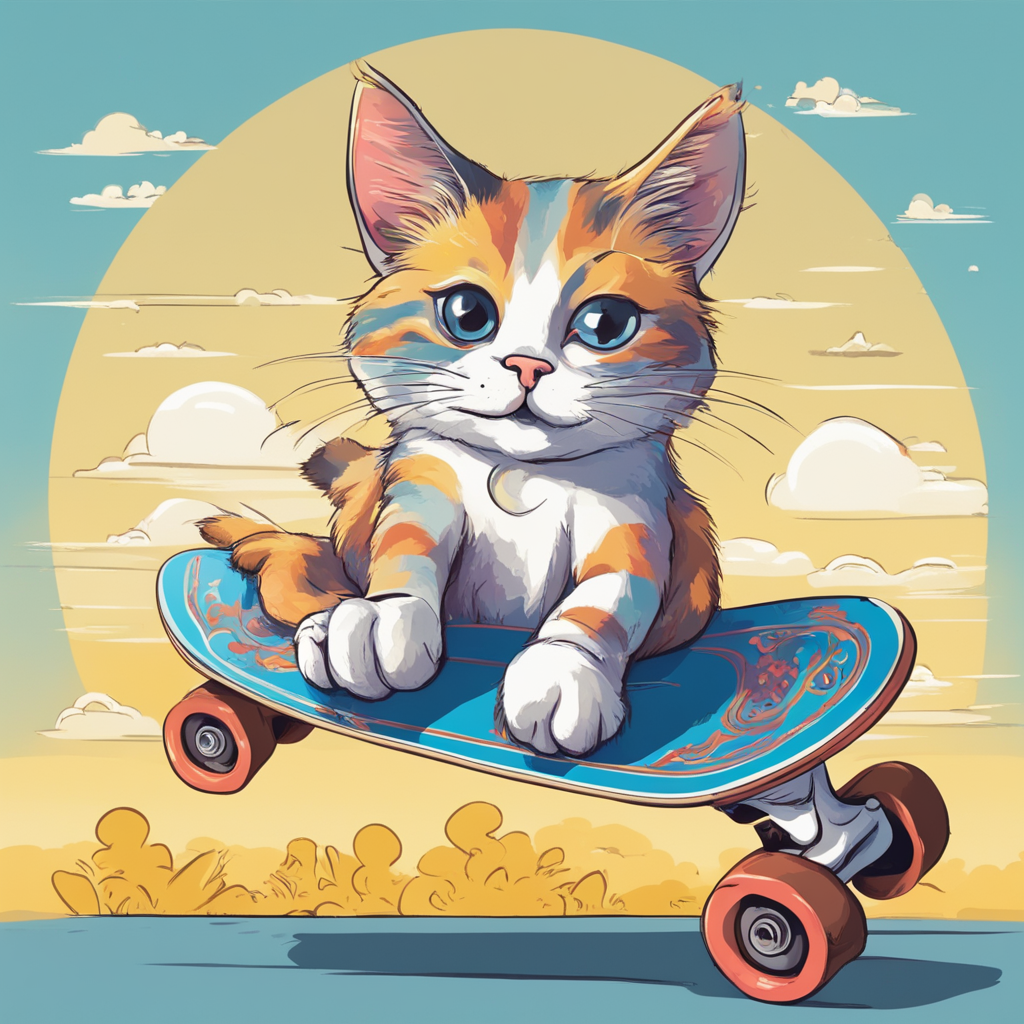

In [3]:
# Give a prompt and run the prompt through both of the models (base and refiner) sequentially
prompt = "A cartoon cat sitting on a skateboard, sunny day, blue sky, vibrant colors"

image = base(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_end=high_noise_frac,
    output_type="latent",
).images

image = refiner(
    prompt=prompt,
    num_inference_steps=n_steps,
    denoising_start=high_noise_frac,
    image=image,
).images[0]

display(image)